# A Tiny Inference Engine — Paged KV-Cache + Speculative Decoding

**The capstone** of the inference path: `../nanogpt-from-scratch` → `../kv-cache` → `../rope` →
here. We build the two ideas that make real LLM serving (vLLM, TGI, TensorRT-LLM) fast and
memory-efficient, in NumPy — each **proven** to keep the output identical.

By the end you will:
- Build a **paged KV-cache** (fixed blocks + block table — vLLM's core) and prove it's transparent
- Build **speculative decoding** (a cheap draft model, verified by the target) and prove greedy
  speculative output is *exactly* the target's greedy output
- Measure the real win: same text, far fewer expensive target forward passes


---
## 0 · A fast forward pass isn't enough

You built a model (`nanogpt`) and made single-stream generation linear (`kv-cache`). But
*serving* has two more problems:

1. **Memory:** one contiguous KV-cache per sequence, each a different length, fragments GPU
   memory — you can't pack many users in.
2. **Latency:** generation is one forward per token and memory-bound; the GPU is underused.

Paged KV-cache solves (1); speculative decoding solves (2). Both must not change what the
model says — so we prove output-equivalence for each.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from engine import (
    PagedKVCache, verify_paging,
    greedy_target, speculative_greedy, verify_speculative, _train_pair,
)

plt.rcParams.update({
    "figure.facecolor": "#0f1117", "axes.facecolor": "#1a1d27",
    "axes.edgecolor": "#2a2d3e", "axes.labelcolor": "#e2e8f0",
    "text.color": "#e2e8f0", "xtick.color": "#94a3b8", "ytick.color": "#94a3b8",
    "axes.titlecolor": "#e2e8f0", "grid.color": "#2a2d3e", "figure.dpi": 110,
})
target, draft, tok = _train_pair()   # a good 2-layer target + a cheap 1-layer draft
print("target & draft ready | vocab", tok.vocab_size)

target & draft ready | vocab 14


---
## 1 · Paged KV-cache — memory in fixed blocks

`../kv-cache` grew one contiguous array per sequence. `PagedKVCache` instead hands out memory
in fixed-size **pages** and keeps a list of blocks per layer (a "block table"). When a page
fills, allocate another. This is exactly how an OS gives a process memory in pages — and how
vLLM packs many sequences into the GPU without fragmentation or giant reallocations.

The attention step still sees a normal contiguous view, so the verified `decode_step` from
`../kv-cache` runs **unchanged** on top of it.


In [2]:
ids = tok.encode("to be or not to be")
cache = PagedKVCache(n_layer=2, page_size=4)
for t in ids:
    from engine import decode_step  # reused from ../kv-cache via engine
    decode_step(target, t, cache)
print(f"stored {cache.length()} tokens in {cache.n_blocks()} fixed blocks of size 4")
print("blocks were allocated on demand — no one big contiguous buffer.")

stored 18 tokens in 10 fixed blocks of size 4
blocks were allocated on demand — no one big contiguous buffer.


---
## 2 · Paging is transparent — prove it

Paging changes *where* K/V live, not their values. So logits must match a contiguous cache at
every position. This is the paged-cache correctness proof.


In [3]:
err = verify_paging(target, ids, page_size=4)
print(f"max |logit diff| paged vs contiguous: {err:.2e}")
print("PASS — paging is transparent." if err < 1e-6 else "FAIL")

max |logit diff| paged vs contiguous: 0.00e+00
PASS — paging is transparent.


---
## 3 · Speculative decoding — a draft model does the guessing

Generation is one target forward per token, and it's memory-bound. Idea: a small, cheap
**draft** model proposes the next `k` tokens; the big **target** model then verifies all `k`
in a **single** forward. With greedy decoding we accept each proposed token while it equals the
target's own argmax, and stop at the first disagreement (taking the target's token there).

The kicker: the accepted sequence is **identical** to what the target would have produced
greedily on its own — we just needed fewer expensive target forwards to get there.


In [4]:
prompt = tok.encode("to be")
ref, greedy_forwards = greedy_target(target, prompt, 60)
spec, spec_forwards = speculative_greedy(target, draft, prompt, 60, k=4)

print("target greedy :", repr(tok.decode(ref)[:50]))
print("speculative   :", repr(tok.decode(spec)[:50]))
print("identical output:", np.array_equal(ref, spec))

target greedy :

 'to be or not to be that is the question. tion. to '
speculative   : 'to be or not to be that is the question. tion. to '
identical output: True


---
## 4 · Prove + measure the win

Same output, fewer target forwards. The speedup depends on how often the cheap draft agrees
with the target — a better draft accepts longer runs.


speculative == target greedy: True


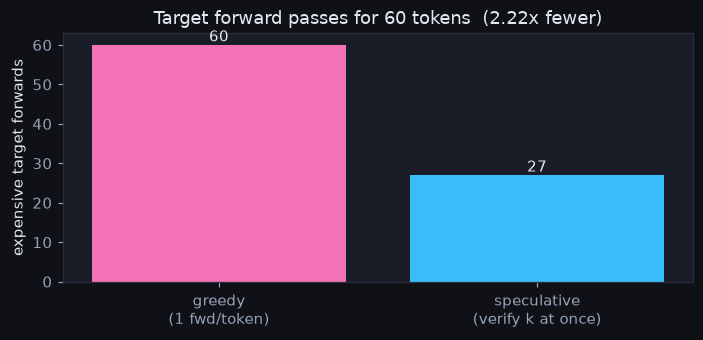

In [5]:
ok, tf = verify_speculative(target, draft, prompt, 60, k=4)
print("speculative == target greedy:", ok)

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.bar(["greedy\n(1 fwd/token)", "speculative\n(verify k at once)"],
       [greedy_forwards, spec_forwards], color=["#f472b6", "#38bdf8"])
for i, v in enumerate([greedy_forwards, spec_forwards]):
    ax.text(i, v, str(v), ha="center", va="bottom")
ax.set(title=f"Target forward passes for 60 tokens  ({greedy_forwards/tf:.2f}x fewer)",
       ylabel="expensive target forwards")
plt.tight_layout(); plt.show()

---
## 5 · Where next

- **Continuous batching:** many sequences share one paged pool, each with its own block table;
  new requests join and finished ones free their blocks mid-flight. That plus paging *is* the
  heart of vLLM.
- **Sampling (not just greedy) speculative decoding:** uses a rejection-sampling correction so
  the output distribution exactly matches the target's — same idea, slightly more math.
- **Real paged-attention kernels:** the CUDA kernel that reads K/V straight from scattered
  blocks. You now understand what it's doing and why.

You can now explain, from first principles, the two techniques that make LLM serving practical.


---
## 6 · Summary

| Piece | Where | Job |
|---|---|---|
| `PagedKVCache` | `engine.py` | KV in fixed blocks + block table (vLLM's core) |
| `verify_paging` | `engine.py` | proof paged logits == contiguous |
| `speculative_greedy` | `engine.py` | draft proposes k, target verifies in one forward |
| `verify_speculative` | `engine.py` | proof spec output == target greedy |

**One line:** page the KV-cache to serve many sequences, and let a cheap draft model batch the
guessing — both make serving faster/cheaper without changing a single output token.
